In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
from spacy import displacy
from spacy import tokenizer
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# set plot options
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_color = "#00bfbf"

In [3]:
data = pd.read_csv('fake_news_data.csv')

In [4]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0, 0.5, 'Count')

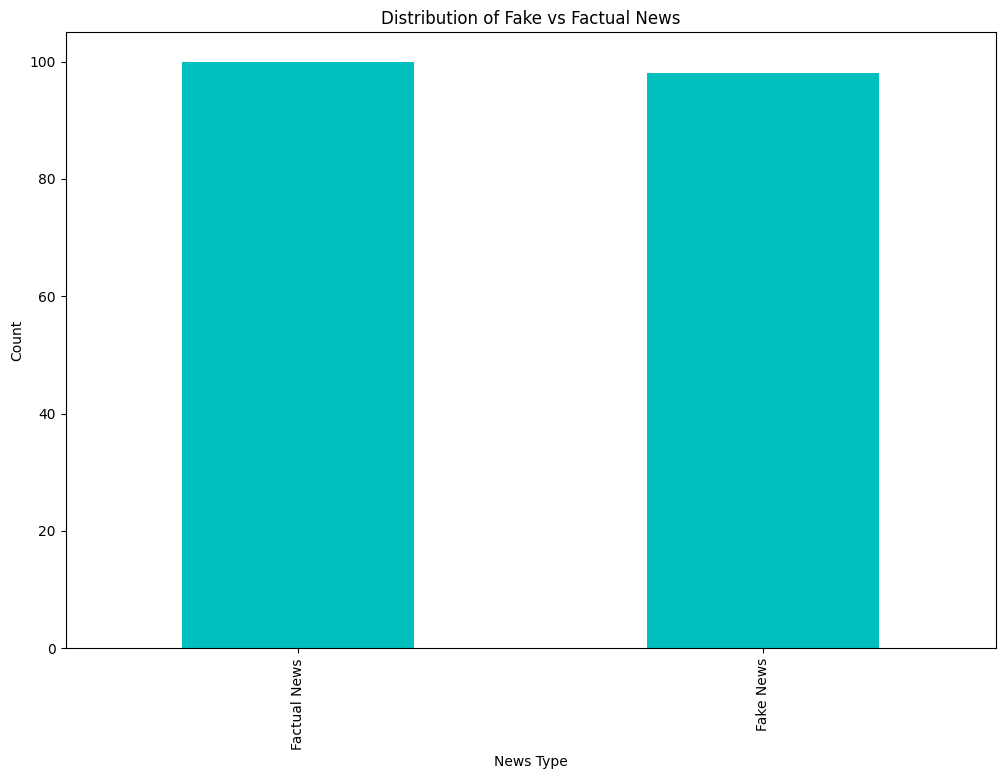

In [6]:
data.fake_or_factual.value_counts().plot(kind='bar', color=default_plot_color)
plt.title('Distribution of Fake vs Factual News')
plt.xlabel('News Type')
plt.ylabel('Count')

### Exploring Data using POS Tagging

In [7]:
nlp = spacy.load('en_core_web_sm')

In [8]:
fake_news = data[data.fake_or_factual == 'Fake News']
fact_news = data[data.fake_or_factual == 'Factual News']

In [9]:
# spacydocs that contains the text and linguistic information spacy generates.
# we use the pipe method for efficient batch processing.
fake_spacydocs = list(nlp.pipe(fake_news.text)) # fake news text and linguistic information
fact_spacydocs = list(nlp.pipe(fact_news.text)) # factual news text and linguistic information

In [10]:
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(token.text, token.ent_type_, token.pos_) for token in doc]

In [11]:
columns = ['token', 'ner_tag', 'pos_tag']
fake_tagsdf = pd.DataFrame(columns=columns)

In [12]:
# extract token, ner tag, and pos tag for each doc in the spacydocs list and store them in a dataframe.
for doc in fake_spacydocs:
    tags = extract_token_tags(doc)
    new_record = pd.DataFrame(tags, columns=columns)
    fake_tagsdf = pd.concat([fake_tagsdf, new_record], ignore_index=True)

In [13]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [14]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [15]:
pos_counts_fake.head(10)

,token,pos_tag,count
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [16]:
columns = ['token', 'ner_tag', 'pos_tag']
fact_tagsdf = pd.DataFrame(columns=columns)

In [17]:
for doc in fact_spacydocs:
    tags = extract_token_tags(doc)
    new_record = pd.DataFrame(tags, columns=columns)
    fact_tagsdf = pd.concat([fact_tagsdf, new_record], ignore_index=True)

In [18]:
pos_counts_fact= fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [19]:
pos_counts_fact.head(10)

,token,pos_tag,count
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [20]:
pos_counts_fake.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
Name: token, dtype: int64

In [21]:
pos_counts_fact.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
Name: token, dtype: int64

In [22]:
pos_counts_fact[pos_counts_fact['pos_tag'] == 'NOUN'].head(10)

,token,pos_tag,count
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
4259,law,NOUN,42


In [23]:
pos_counts_fake[pos_counts_fake['pos_tag'] == 'NOUN'].head(10)

,token,pos_tag,count
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [24]:
tip_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag'] != ''].groupby(['token','ner_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)

In [25]:
tip_entities_fact = fact_tagsdf[fact_tagsdf['ner_tag'] != ''].groupby(['token','ner_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)

In [26]:
# create custom palette to ensure plots are consistent
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Top 10 Named Entities in Fake News')]

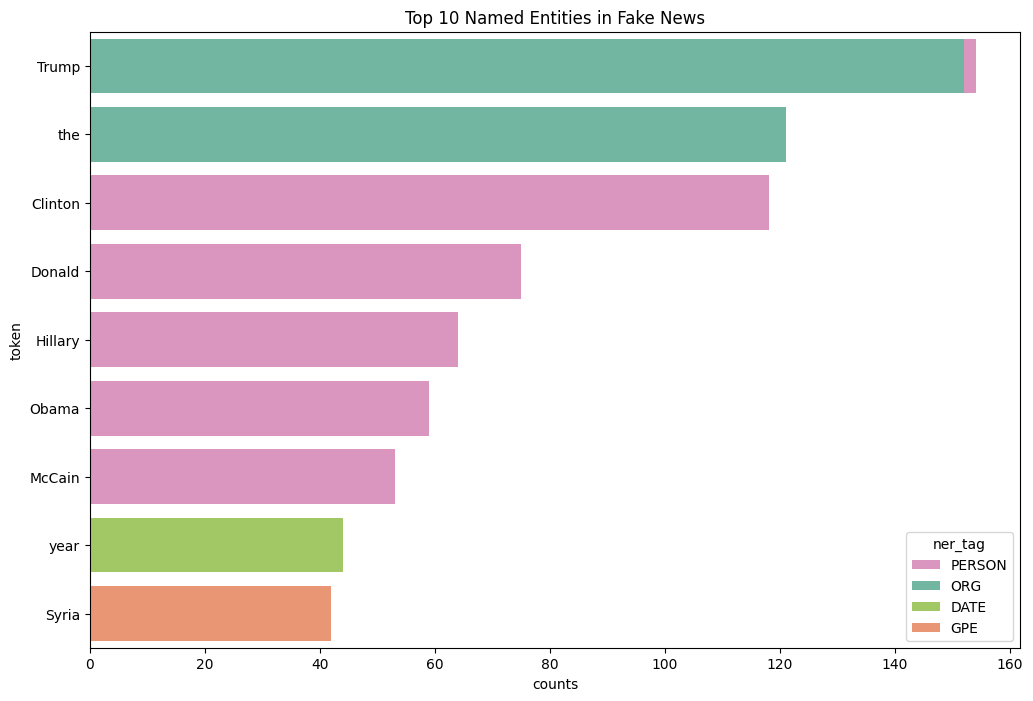

In [27]:
sns.barplot(
    x='counts',
    y='token',
    hue='ner_tag',
    palette=ner_palette,
    data=tip_entities_fake.head(10),
    orient='h',
    dodge=False
).set(title='Top 10 Named Entities in Fake News')

[Text(0.5, 1.0, 'Top 10 Named Entities in Fake News')]

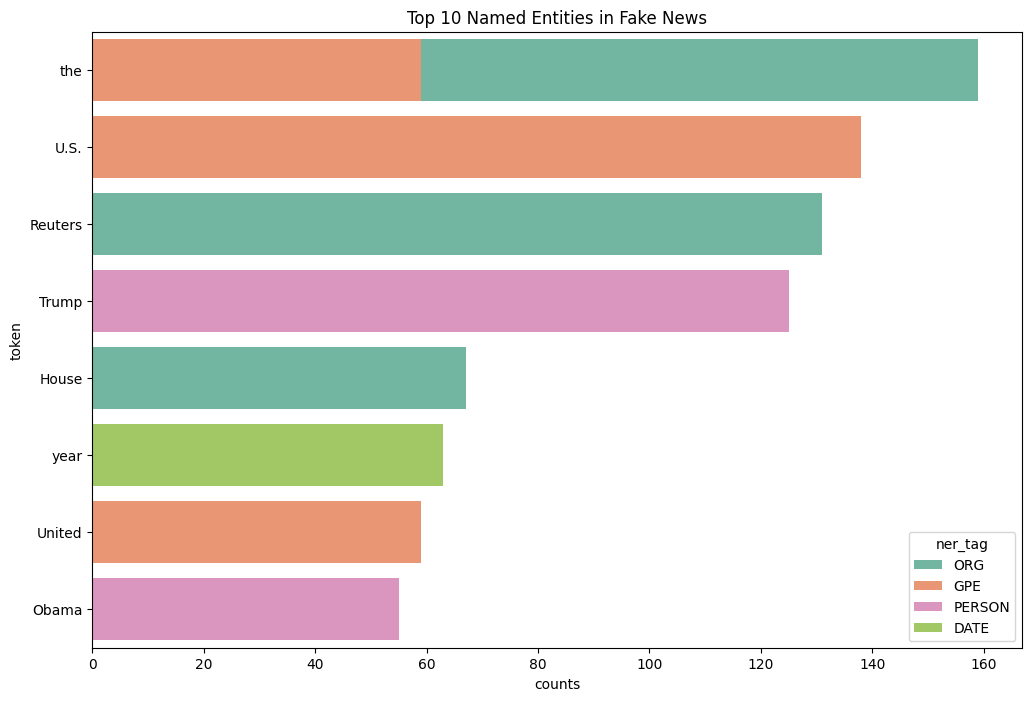

In [28]:
sns.barplot(
    x='counts',
    y='token',
    hue='ner_tag',
    palette=ner_palette,
    data=tip_entities_fact.head(10),
    orient='h',
    dodge=False
).set(title='Top 10 Named Entities in Fake News')

## Text Pre-processing

In [29]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [30]:
data['text_clean'] = data.text.apply(lambda x: re.sub(r'^[^-]*-\s', '', x.lower()))

In [31]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,there are two small problems with your analogy...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried in trump s bonkers interview with new y...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"women make up over 50 percent of this country,..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,u.s. defense secretary jim mattis said on mond...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland s political parties are rapid...


In [32]:
data.text_clean = data.text_clean.str.lower()

In [33]:
data.text_clean = data.text_clean.apply(lambda x: re.sub(r'[^\w\s]', '', x))

In [34]:
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [35]:
data.text_clean = data.text_clean.apply(lambda x: ' '.join([word for word in x.split() if word not in en_stopwords]))

In [36]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,two small problems analogy susan jesus muslim ...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried trump bonkers interview new york times ...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,women make 50 percent country grossly underrep...
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,us defense secretary jim mattis said monday ru...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland political parties rapidly run...


In [37]:
data.text_clean = data.text_clean.apply(lambda x: word_tokenize(x))

In [38]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problems, analogy, susan, jesus, ..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[women, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[us, defense, secretary, jim, mattis, said, mo..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, parties, rapidl..."


In [39]:
lemmatizer = WordNetLemmatizer()

In [40]:
data.text_clean = data.text_clean.apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [41]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [42]:
tokens_clean = sum(data.text_clean, [])

In [56]:
unigrams = pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts().reset_index()
print(unigrams.head(10))

           index  count
0        (said,)    580
1       (trump,)    580
2           (u,)    277
3       (state,)    275
4   (president,)    259
5       (would,)    226
6         (one,)    160
7     (clinton,)    141
8        (year,)    139
9  (republican,)    137


In [62]:
bigrams = pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts().reset_index()
print(bigrams.head(10))

                     index  count
0          (donald, trump)    113
1          (united, state)     84
2           (white, house)     74
3      (president, donald)     47
4       (hillary, clinton)     39
5              (new, york)     33
6         (supreme, court)     30
7             (image, via)     29
8         (official, said)     26
9  (trump, administration)     26


In [48]:
trigrams = pd.Series(nltk.ngrams(tokens_clean, 3)).value_counts()
print(trigrams.head(10))

(president, donald, trump)       46
(president, barack, obama)       14
(new, york, time)                11
(u, president, donald)           10
(white, house, official)         10
(food, stamp, fraud)             10
(fbi, director, james)            8
(director, james, comey)          8
(high, school, student)           7
(national, security, adviser)     7
Name: count, dtype: int64


In [58]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

C:\Users\Faruq\AppData\Local\Temp\ipykernel_24528\2971004317.py:1: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most common unigrams after preprocessing')]

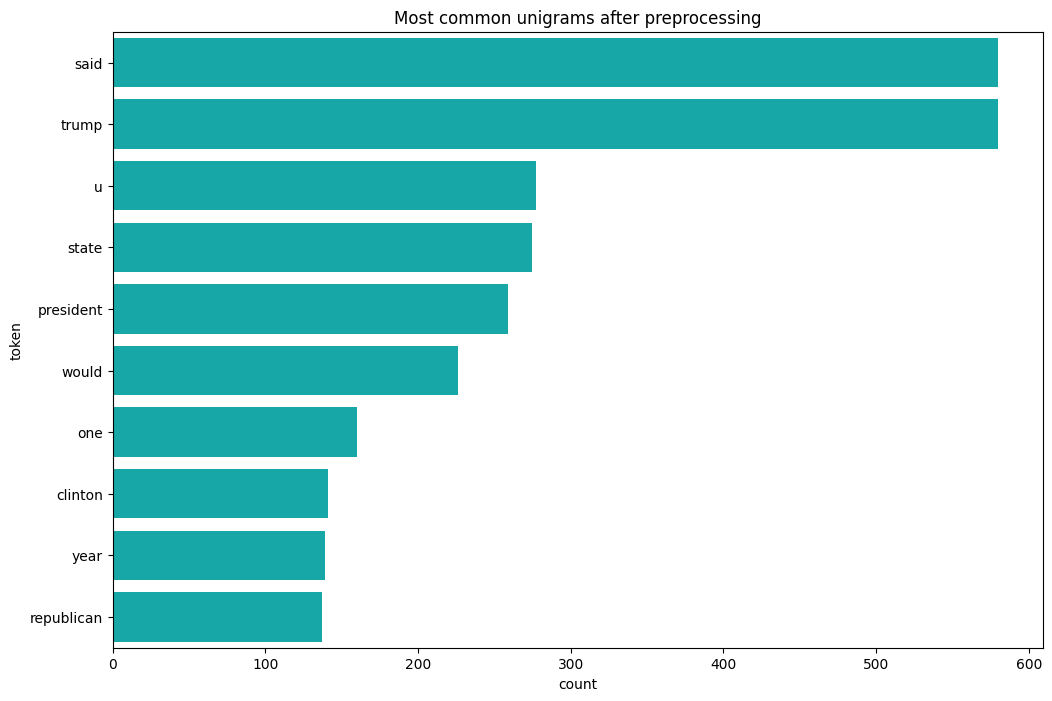

In [61]:
sns.barplot(
    x='count',
    y='token',
    hue='token',
    data=unigrams.head(10),
    orient='h',
    palette=[default_plot_color]
).set(title='Most common unigrams after preprocessing')

C:\Users\Faruq\AppData\Local\Temp\ipykernel_24528\4286002127.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most common bigrams after preprocessing')]

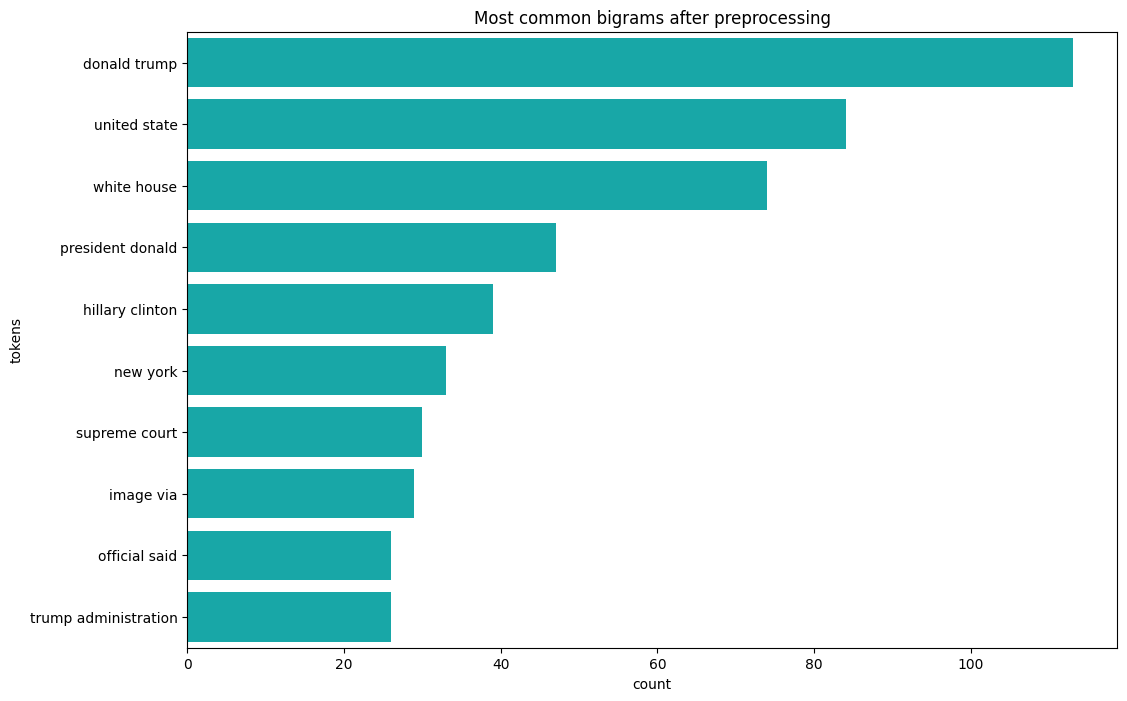

In [65]:
bigrams['tokens'] = bigrams['index'].apply(lambda x: ' '.join(x))

sns.barplot(
    x='count',
    y='tokens',
    hue='tokens',
    data=bigrams.head(10),
    orient='h',
    palette=[default_plot_color]
).set(title='Most common bigrams after preprocessing')